In [ ]:
!nvidia-smi

Tue Aug 11 15:54:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   47C    P0             28W /   72W |    2166MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -U transformers accelerate peft trl datasets bitsandbytes scikit-learn pandas

In [ ]:
!nvidia-smi

Tue Aug 11 15:54:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   48C    P0             28W /   72W |    2166MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
import os

PROJECT_DIR = "/content/drive/MyDrive/shopping_assistant_gemma_lora"
DATA_DIR = f"{PROJECT_DIR}/data"
OUTPUT_DIR = f"{PROJECT_DIR}/outputs/gemma-3-1b-it-main-category-lora"

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/shopping_assistant_gemma_lora


In [12]:
import json

DATA_PATH = f"{DATA_DIR}/lora_main_category_balanced_sample.jsonl"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        item = json.loads(line)
        print(item)
        if i == 2:
            break

{'instruction': 'Classify the product into one main category.', 'input': 'Title: EENOUR Tumbler Heat Press Machine for 30oz 20oz Subliamtion Blank Skinny Tumbler Glass Jar Can - Heat Transfer Vinyl Mug Press with Temp&Timer Setting for 11-16oz Coffee/Ceramic Mug Cup - Purple', 'output': 'Arts, Crafts & Party Supplies'}
{'instruction': 'Classify the product into one main category.', 'input': 'Title: 20 x 24 Inch Pre-Stretched Aluminum Silk Screen Printing Frames with 160 White Mesh (6 Pack Screens)', 'output': 'Arts, Crafts & Party Supplies'}
{'instruction': 'Classify the product into one main category.', 'input': 'Title: Edimax Wi-Fi 5 Nano 802.11ac AC1200 Dual-Band Adapter for PC, Wireless AC USB Adapter Dongle, Up to 867Mbps (5GHz) / 300Mbps (2.4GHz) Fast Transfer, Win 11 Plug-n-Play, Mac OS, Linux, EW-7822ULC', 'output': 'Electronics & Computers'}


In [ ]:
from huggingface_hub import login

login()

In [ ]:
MODEL_NAME = "google/gemma-3-1b-it"

In [13]:
from datasets import load_dataset

dataset = load_dataset("json", data_files=DATA_PATH, split="train")

dataset = dataset.train_test_split(
    test_size=0.1,
    seed=42
)

# reduce training data to save time
dataset["train"] = dataset["train"].shuffle(seed=42).select(
    range(min(10000, len(dataset["train"])))
)

dataset["test"] = dataset["test"].shuffle(seed=42).select(
    range(min(1000, len(dataset["test"])))
)

print(dataset)
print(dataset["train"][0])

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 1000
    })
})
{'instruction': 'Classify the product into one main category.', 'input': 'Title: Small Oil Diffuser Aromatherapy Diffusers for Esential Oils,150ml Oil Diffuser for Home with 7 -Color Light Atomizer for Desk Home Office Gifts', 'output': 'Health & Household'}


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "google/gemma-3-1b-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


def format_example(example):
    prompt = f"""You are a product classification assistant.
Classify the product into exactly one main category.
Output only the category label.

{example["instruction"]}
{example["input"]}

Answer:
{example["output"]}"""
    return {"text": prompt}


dataset = dataset.map(format_example)

print(dataset["train"][0]["text"])

You are a product classification assistant.
Classify the product into exactly one main category.
Output only the category label.

Classify the product into one main category.
Title: Small Oil Diffuser Aromatherapy Diffusers for Esential Oils,150ml Oil Diffuser for Home with 7 -Color Light Atomizer for Desk Home Office Gifts

Answer:
Health & Household


In [ ]:
!pip install -U "bitsandbytes>=0.46.1"
!pip install -U transformers accelerate peft trl datasets

In [ ]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    dtype=torch.bfloat16,
)

model.config.use_cache = False

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

In [ ]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
)

In [ ]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    learning_rate=2e-4,
    num_train_epochs=1,

    logging_steps=20,
    eval_strategy="steps",
    eval_steps=500,
    save_steps=500,
    save_total_limit=2,

    bf16=True,

    optim="adamw_torch",

    report_to="none",

    # Gemma 1B + L4 no need checkpointing
    gradient_checkpointing=False,

    dataset_text_field="text",
    max_length=512,
    packing=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    peft_config=lora_config,
    processing_class=tokenizer,
)

trainer.train()

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Saved to:", OUTPUT_DIR)

Adding EOS to train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/10000 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
500,1.458840,1.475110,1.456635,666941.000000,0.727973
625,1.430246,1.465539,1.454160,832891.000000,0.728479


Saved to: /content/drive/MyDrive/shopping_assistant_gemma_lora/outputs/gemma-3-1b-it-main-category-lora


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

BASE_MODEL = "google/gemma-3-1b-it"
ADAPTER_PATH = OUTPUT_DIR

# load tokenizer
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_PATH)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# load base model
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    device_map="auto",
    dtype=torch.bfloat16,
)

# load LoRA adapter
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()


def predict_category_lora(title):
    prompt = f"""You are a product classification assistant.
Classify the product into exactly one main category.
Output only the category label.

Classify the product into one main category.
Title: {title}

Answer:
"""

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    response = tokenizer.decode(generated, skip_special_tokens=True)

    return response.strip()


print("LoRA model predictions:")
print(predict_category_lora("Apple AirPods Pro Wireless Earbuds with Active Noise Cancellation"))
print(predict_category_lora("Sion Softside Expandable Roller Luggage, Black, Checked-Large 29-Inch"))
print(predict_category_lora("CeraVe Moisturizing Cream for Dry Skin"))
print(predict_category_lora("LEGO Star Wars Millennium Falcon Building Set"))
print(predict_category_lora("Logitech G305 LIGHTSPEED Wireless Gaming Mouse"))

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

LoRA model predictions:
Electronics & Computers
Fashion, Shoes & Luggage
Baby Products
Baby Products
Smart Home


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import re

def clean_label(text):
    text = text.strip()
    text = text.split("\n")[0].strip()
    text = re.sub(r"^[\"'\s]+|[\"'\s]+$", "", text)
    text = text.replace("Answer:", "").strip()
    return text


y_true_lora = []
y_pred_lora = []

test_data = dataset["test"]

for ex in test_data:
    title = ex["input"].replace("Title:", "").strip()
    true_label = ex["output"].strip()

    pred_label = predict_category_lora(title)
    pred_label = clean_label(pred_label)

    y_true_lora.append(true_label)
    y_pred_lora.append(pred_label)

label_list = sorted(set(dataset["train"]["output"]))
allowed_labels = set(label_list)

acc_lora = accuracy_score(y_true_lora, y_pred_lora)
macro_precision_lora = precision_score(
    y_true_lora, y_pred_lora, labels=label_list, average="macro", zero_division=0
)
macro_recall_lora = recall_score(
    y_true_lora, y_pred_lora, labels=label_list, average="macro", zero_division=0
)
macro_f1_lora = f1_score(y_true_lora, y_pred_lora, average="macro")
weighted_f1_lora = f1_score(y_true_lora, y_pred_lora, average="weighted")
balanced_acc_lora = balanced_accuracy_score(y_true_lora, y_pred_lora)
exact_label_compliance_lora = sum(
    pred in allowed_labels for pred in y_pred_lora
) / len(y_pred_lora)

print("===== Gemma 3 1B IT + LoRA Evaluation =====")
print("Accuracy:", acc_lora)
print("Macro Precision:", macro_precision_lora)
print("Macro Recall:", macro_recall_lora)
print("Macro F1:", macro_f1_lora)
print("Weighted F1:", weighted_f1_lora)
print("Balanced Accuracy:", balanced_acc_lora)
print("Exact Label Compliance:", exact_label_compliance_lora)

print("\nClassification Report:")
print(label_list)
print("Number of labels:", len(label_list))
print(classification_report(
    y_true_lora,
    y_pred_lora,
    labels=label_list,
    zero_division=0
))


===== Gemma 3 1B IT + LoRA Evaluation =====
Accuracy: 0.935
Macro Precision: 0.9374562299957272
Macro Recall: 0.9255236966060576
Macro F1: 0.8264082165193323
Weighted F1: 0.935405029443619
Balanced Accuracy: 0.9255236966060576
Exact Label Compliance: 0.998

Classification Report:
['Arts, Crafts & Party Supplies', 'Automotive', 'Baby Products', 'Beauty & Personal Care', 'Electronics & Computers', 'Fashion, Shoes & Luggage', 'Gift Cards', 'Health & Household', 'Home & Kitchen', 'Industrial & Scientific', 'Pet Supplies', 'Smart Home', 'Sports & Outdoors', 'Tools & Home Improvement', 'Toys & Games', 'Video Games']
Number of labels: 16
                               precision    recall  f1-score   support

Arts, Crafts & Party Supplies       0.99      0.94      0.97        89
                   Automotive       0.97      0.95      0.96        78
                Baby Products       0.90      0.91      0.90        67
       Beauty & Personal Care       0.94      0.98      0.96        64
     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

BASE_MODEL = "google/gemma-3-1b-it"

base_tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token

base_only_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    device_map="auto",
    dtype=torch.bfloat16,
)

base_only_model.eval()

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 1152, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=1152, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1152, out_features=256, bias=False)
          (v_proj): Linear(in_features=1152, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1152, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (up_proj): Linear(in_features=1152, out_features=6912, bias=False)
          (down_proj): Linear(in_features=6912, out_features=1152, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((1152,), e

In [ ]:
label_list = sorted(set(dataset["train"]["output"]))

def predict_category_base_with_labels(title):
    labels_text = "\n".join([f"- {label}" for label in label_list])

    prompt = f"""You are a product classification assistant.
Classify the product into exactly one category from the allowed label list.
Output only one label from the list.

Allowed labels:
{labels_text}

Product title:
{title}

Answer:
"""

    inputs = base_tokenizer(prompt, return_tensors="pt").to(base_only_model.device)

    with torch.no_grad():
        outputs = base_only_model.generate(
            **inputs,
            max_new_tokens=30,
            do_sample=False,
            pad_token_id=base_tokenizer.eos_token_id,
        )

    generated = outputs[0][inputs["input_ids"].shape[1]:]
    response = base_tokenizer.decode(generated, skip_special_tokens=True)

    return clean_label(response)
    return response.strip()

In [ ]:
print("Base model zero-shot predictions:")
print(predict_category_base_with_labels("Apple AirPods Pro Wireless Earbuds with Active Noise Cancellation"))
print(predict_category_base_with_labels("Sion Softside Expandable Roller Luggage, Black, Checked-Large 29-Inch"))
print(predict_category_base_with_labels("CeraVe Moisturizing Cream for Dry Skin"))

Base model zero-shot predictions:
Electronics & Computers
Sports & Outdoors
Health & Household


In [ ]:
y_true_base = []
y_pred_base = []

for ex in dataset["test"]:
    title = ex["input"].replace("Title:", "").strip()
    true_label = ex["output"].strip()

    pred_label = predict_category_base_with_labels(title)
    pred_label = clean_label(pred_label)

    y_true_base.append(true_label)
    y_pred_base.append(pred_label)

acc_base = accuracy_score(y_true_base, y_pred_base)
macro_precision_base = precision_score(
    y_true_base, y_pred_base, labels=label_list, average="macro", zero_division=0
)
macro_recall_base = recall_score(
    y_true_base, y_pred_base, labels=label_list, average="macro", zero_division=0
)
macro_f1_base = f1_score(y_true_base, y_pred_base, average="macro")
weighted_f1_base = f1_score(y_true_base, y_pred_base, average="weighted")
balanced_acc_base = balanced_accuracy_score(y_true_base, y_pred_base)
exact_label_compliance_base = sum(
    pred in allowed_labels for pred in y_pred_base
) / len(y_pred_base)

print("===== Gemma 3 1B IT Prompt-Only Evaluation =====")
print("Accuracy:", acc_base)
print("Macro Precision:", macro_precision_base)
print("Macro Recall:", macro_recall_base)
print("Macro F1:", macro_f1_base)
print("Weighted F1:", weighted_f1_base)
print("Balanced Accuracy:", balanced_acc_base)
print("Exact Label Compliance:", exact_label_compliance_base)

print("\nClassification Report:")
print(classification_report(
    y_true_base,
    y_pred_base,
    labels=label_list,
    zero_division=0
))


===== Gemma 3 1B IT Prompt-Only Evaluation =====
Accuracy: 0.34
Macro Precision: 0.5498005186359143
Macro Recall: 0.3306139543291819
Macro F1: 0.133596645730281
Weighted F1: 0.3130100060745899
Balanced Accuracy: 0.3306139543291819
Exact Label Compliance: 0.945

Classification Report:
                               precision    recall  f1-score   support

Arts, Crafts & Party Supplies       0.18      0.97      0.31        89
                   Automotive       0.91      0.62      0.73        78
                Baby Products       0.00      0.00      0.00        67
       Beauty & Personal Care       1.00      0.42      0.59        64
      Electronics & Computers       0.44      0.56      0.49        71
     Fashion, Shoes & Luggage       0.75      0.30      0.42        61
                   Gift Cards       1.00      0.33      0.50         3
           Health & Household       0.39      0.56      0.46        57
               Home & Kitchen       0.55      0.61      0.58        76
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [ ]:
comparison_df = pd.DataFrame([
    {
        "Model": "Gemma 3 1B IT Prompt-only",
        "Accuracy": acc_base,
        "Macro Precision": macro_precision_base,
        "Macro Recall": macro_recall_base,
        "Macro F1": macro_f1_base,
        "Weighted F1": weighted_f1_base,
        "Balanced Accuracy": balanced_acc_base,
        "Exact Label Compliance": exact_label_compliance_base,
    },
    {
        "Model": "Gemma 3 1B IT + LoRA",
        "Accuracy": acc_lora,
        "Macro Precision": macro_precision_lora,
        "Macro Recall": macro_recall_lora,
        "Macro F1": macro_f1_lora,
        "Weighted F1": weighted_f1_lora,
        "Balanced Accuracy": balanced_acc_lora,
        "Exact Label Compliance": exact_label_compliance_lora,
    }
])

display(comparison_df)

comparison_df.to_csv(
    f"{PROJECT_DIR}/gemma_lora_vs_prompt_only_results.csv",
    index=False
)

print(
    "Saved comparison results to:",
    f"{PROJECT_DIR}/gemma_lora_vs_prompt_only_results.csv"
)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,Exact Label Compliance
0,Gemma 3 1B IT Prompt-only,0.340,0.549801,0.330614,0.133597,0.313010,0.330614,0.945
1,Gemma 3 1B IT + LoRA,0.935,0.937456,0.925524,0.826408,0.935405,0.925524,0.998


Saved comparison results to: /content/drive/MyDrive/shopping_assistant_gemma_lora/gemma_lora_vs_prompt_only_results.csv


In [ ]:
print(dataset["train"][0])
print(dataset["test"][0])

unique_labels = sorted(set(dataset["train"]["output"]))
print("Number of labels:", len(unique_labels))
print(unique_labels[:50])

{'instruction': 'Classify the product into one main category.', 'input': 'Title: Small Oil Diffuser Aromatherapy Diffusers for Esential Oils,150ml Oil Diffuser for Home with 7 -Color Light Atomizer for Desk Home Office Gifts', 'output': 'Health & Household', 'text': 'You are a product classification assistant.\nClassify the product into exactly one main category.\nOutput only the category label.\n\nClassify the product into one main category.\nTitle: Small Oil Diffuser Aromatherapy Diffusers for Esential Oils,150ml Oil Diffuser for Home with 7 -Color Light Atomizer for Desk Home Office Gifts\n\nAnswer:\nHealth & Household'}
{'instruction': 'Classify the product into one main category.', 'input': 'Title: Paasche Airbrush AEC-K Air Eraser Etching Tool, None', 'output': 'Arts, Crafts & Party Supplies', 'text': 'You are a product classification assistant.\nClassify the product into exactly one main category.\nOutput only the category label.\n\nClassify the product into one main category.\n

In [ ]:
train_titles = set([x.replace("Title:", "").strip() for x in dataset["train"]["input"]])
test_titles = set([x.replace("Title:", "").strip() for x in dataset["test"]["input"]])

overlap = train_titles.intersection(test_titles)

print("Train unique titles:", len(train_titles))
print("Test unique titles:", len(test_titles))
print("Exact title overlap:", len(overlap))
print(list(overlap)[:20])

Train unique titles: 9983
Test unique titles: 999
Exact title overlap: 4
['Carabelle Studio Printmaking and Etching, Multicolor', 'VEVOR Heat Press Machine,10x12inches Portable Shirt Printing Multifunctional Sublimation Transfer Heat Press Machine Teflon Coated, Easy Iron-on Press for T-Shirts/Pillows/Bags/HTV Vinyl Projects', 'All-Purpose Liquid Dye, 8 Fluid Ounce (Dark Green)', 'Amazon.com Gift Card in a Greeting Card (Various Designs)']


In [ ]:
allowed_labels = set(label_list)
invalid_lora_preds = sorted(set(y_pred_lora) - allowed_labels)

print("Invalid LoRA labels:", len(invalid_lora_preds))
print(invalid_lora_preds[:50])

Invalid LoRA labels: 2
['Fashion Footwear', 'Health & Fitness']


## Latent-Space Visualization: Before vs. After LoRA Fine-Tuning

This section compares the internal representation of the prompt-only base Gemma model
with the LoRA fine-tuned Gemma model.

For each product title, we feed the same classification prompt into both models and
extract the final-layer hidden representation at the last non-padding token.
The resulting high-dimensional vectors are L2-normalized and projected into the
same 2-D PCA space so that the before/after plots use a common coordinate system.

If fine-tuning has learned the project-specific 16-category taxonomy, samples from
the same category should tend to become more compact and/or better separated after
fine-tuning. The Silhouette Score is also reported as a quantitative summary of
cluster separation (higher is better).


In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

# Keep this moderate because output_hidden_states requires extra GPU memory.
LATENT_SAMPLE_SIZE = 400
LATENT_BATCH_SIZE = 4
LATENT_SEED = 42

latent_data = dataset["test"].shuffle(seed=LATENT_SEED).select(
    range(min(LATENT_SAMPLE_SIZE, len(dataset["test"])))
)

latent_titles = [
    ex["input"].replace("Title:", "").strip()
    for ex in latent_data
]
latent_labels = [ex["output"].strip() for ex in latent_data]

def build_latent_prompt(title):
    return f"""You are a product classification assistant.
Classify the product into exactly one main category.
Output only the category label.

Classify the product into one main category.
Title: {title}

Answer:
"""

def extract_last_token_representations(
    current_model,
    current_tokenizer,
    titles,
    batch_size=4,
):
    """
    Extract one latent vector per title from the final transformer hidden layer.
    We use the hidden state of the last non-padding prompt token.
    """
    current_model.eval()
    vectors = []

    model_device = next(current_model.parameters()).device

    for start in range(0, len(titles), batch_size):
        batch_titles = titles[start:start + batch_size]
        prompts = [build_latent_prompt(title) for title in batch_titles]

        encoded = current_tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        )
        encoded = {k: v.to(model_device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = current_model(
                **encoded,
                output_hidden_states=True,
                return_dict=True,
                use_cache=False,
            )

        # [batch, seq_len, hidden_dim]
        last_hidden = outputs.hidden_states[-1]

        # Index of last non-padding token for each sample.
        last_indices = encoded["attention_mask"].sum(dim=1) - 1
        batch_indices = torch.arange(
            last_hidden.size(0),
            device=last_hidden.device
        )

        batch_vectors = last_hidden[batch_indices, last_indices]
        vectors.append(batch_vectors.float().cpu().numpy())

        del outputs, last_hidden, batch_vectors
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return np.concatenate(vectors, axis=0)


print("Extracting latent representations from base Gemma...")
base_latent = extract_last_token_representations(
    base_only_model,
    base_tokenizer,
    latent_titles,
    batch_size=LATENT_BATCH_SIZE,
)

print("Extracting latent representations from LoRA fine-tuned Gemma...")
lora_latent = extract_last_token_representations(
    model,
    tokenizer,
    latent_titles,
    batch_size=LATENT_BATCH_SIZE,
)

print("Base latent shape:", base_latent.shape)
print("LoRA latent shape:", lora_latent.shape)

# Normalize before PCA so comparison emphasizes direction / semantic structure.
base_latent_norm = normalize(base_latent)
lora_latent_norm = normalize(lora_latent)

# Fit ONE PCA on the concatenated representations so both visualizations
# share exactly the same PCA coordinate system.
joint_latent = np.vstack([base_latent_norm, lora_latent_norm])

pca = PCA(n_components=2, random_state=LATENT_SEED)
joint_2d = pca.fit_transform(joint_latent)

n = len(base_latent_norm)
base_2d = joint_2d[:n]
lora_2d = joint_2d[n:]

print(
    "Explained variance by first two PCs:",
    pca.explained_variance_ratio_.sum()
)

# Quantitative latent-space comparison.
# Silhouette is computed in the normalized high-dimensional space,
# not on the 2-D PCA visualization.
base_silhouette = silhouette_score(
    base_latent_norm,
    latent_labels,
    metric="cosine"
)
lora_silhouette = silhouette_score(
    lora_latent_norm,
    latent_labels,
    metric="cosine"
)

print("Base Gemma Silhouette Score:", base_silhouette)
print("LoRA Gemma Silhouette Score:", lora_silhouette)


Extracting latent representations from base Gemma...
Extracting latent representations from LoRA fine-tuned Gemma...
Base latent shape: (400, 1152)
LoRA latent shape: (400, 1152)
Explained variance by first two PCs: 0.38269508
Base Gemma Silhouette Score: -0.16642072796821594
LoRA Gemma Silhouette Score: -0.11275035887956619


In [16]:
label_list = sorted(set(dataset["train"]["output"]))

print("Number of labels:", len(label_list))
print(label_list)

Number of labels: 16
['Arts, Crafts & Party Supplies', 'Automotive', 'Baby Products', 'Beauty & Personal Care', 'Electronics & Computers', 'Fashion, Shoes & Luggage', 'Gift Cards', 'Health & Household', 'Home & Kitchen', 'Industrial & Scientific', 'Pet Supplies', 'Smart Home', 'Sports & Outdoors', 'Tools & Home Improvement', 'Toys & Games', 'Video Games']


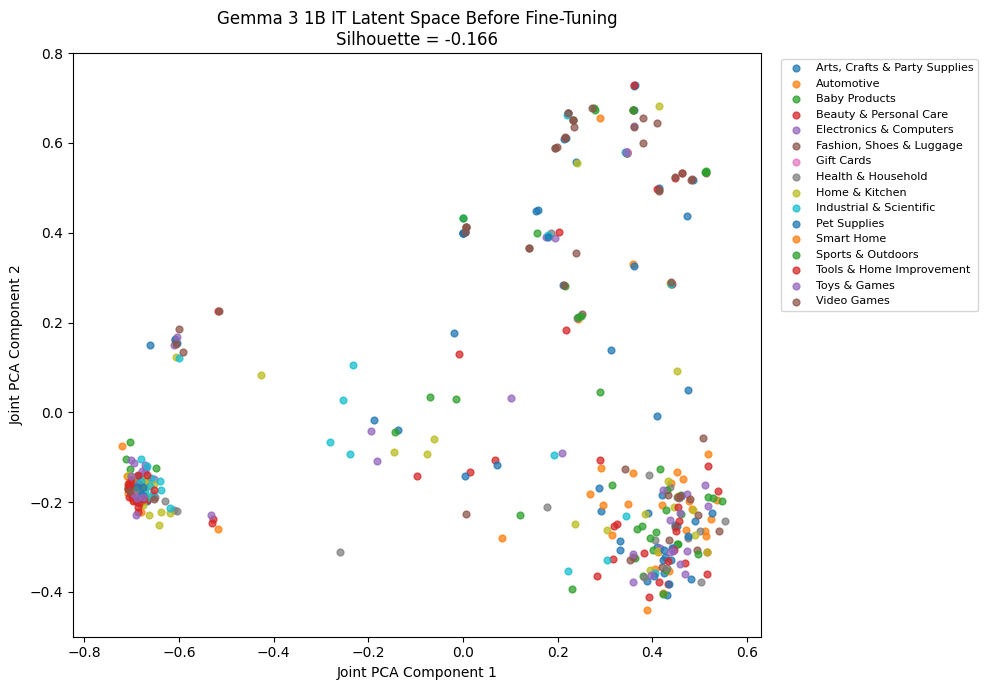

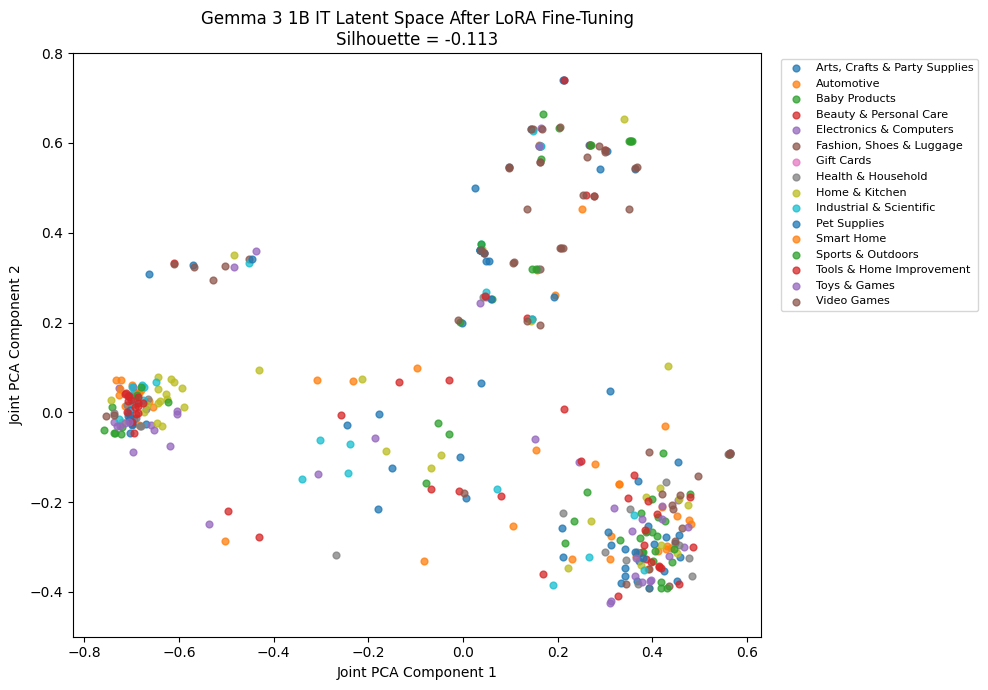

In [17]:
# Use identical axis limits for a fair visual comparison.
all_x = np.concatenate([base_2d[:, 0], lora_2d[:, 0]])
all_y = np.concatenate([base_2d[:, 1], lora_2d[:, 1]])

x_margin = 0.05 * (all_x.max() - all_x.min() + 1e-8)
y_margin = 0.05 * (all_y.max() - all_y.min() + 1e-8)

x_limits = (all_x.min() - x_margin, all_x.max() + x_margin)
y_limits = (all_y.min() - y_margin, all_y.max() + y_margin)

# BEFORE fine-tuning
plt.figure(figsize=(10, 7))
for label in label_list:
    idx = np.array(latent_labels) == label
    if idx.any():
        plt.scatter(
            base_2d[idx, 0],
            base_2d[idx, 1],
            s=24,
            alpha=0.75,
            label=label,
        )

plt.xlim(x_limits)
plt.ylim(y_limits)
plt.xlabel("Joint PCA Component 1")
plt.ylabel("Joint PCA Component 2")
plt.title(
    f"Gemma 3 1B IT Latent Space Before Fine-Tuning\n"
    f"Silhouette = {base_silhouette:.3f}"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# AFTER fine-tuning
plt.figure(figsize=(10, 7))
for label in label_list:
    idx = np.array(latent_labels) == label
    if idx.any():
        plt.scatter(
            lora_2d[idx, 0],
            lora_2d[idx, 1],
            s=24,
            alpha=0.75,
            label=label,
        )

plt.xlim(x_limits)
plt.ylim(y_limits)
plt.xlabel("Joint PCA Component 1")
plt.ylabel("Joint PCA Component 2")
plt.title(
    f"Gemma 3 1B IT Latent Space After LoRA Fine-Tuning\n"
    f"Silhouette = {lora_silhouette:.3f}"
)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### Interpretation Notes

- **Macro Precision**: average class precision with all 16 categories weighted equally.
- **Macro Recall**: average class recall with all 16 categories weighted equally.
- **Balanced Accuracy**: for this single-label multiclass setting, it is the average
  recall across classes and is therefore closely related to Macro Recall.
- **Exact Label Compliance**: fraction of generated predictions that exactly match
  one of the 16 allowed category strings. A semantically reasonable but differently
  named category is counted as non-compliant.
- **Silhouette Score**: compares within-category compactness against between-category
  separation in latent space. Higher values indicate better category separation.

The PCA figures are visualization tools; the Silhouette Score is computed from the
original normalized hidden vectors rather than the 2-D projection.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

# Linear Probe Settings

PROBE_TRAIN_SIZE = 800
PROBE_TEST_SIZE = 400
PROBE_SEED = 42

probe_train_data = dataset["train"].shuffle(seed=PROBE_SEED).select(
    range(min(PROBE_TRAIN_SIZE, len(dataset["train"])))
)

probe_test_data = dataset["test"].shuffle(seed=PROBE_SEED).select(
    range(min(PROBE_TEST_SIZE, len(dataset["test"])))
)

probe_train_titles = [
    ex["input"].replace("Title:", "").strip()
    for ex in probe_train_data
]

probe_test_titles = [
    ex["input"].replace("Title:", "").strip()
    for ex in probe_test_data
]

y_probe_train = [ex["output"].strip() for ex in probe_train_data]
y_probe_test = [ex["output"].strip() for ex in probe_test_data]


# Extract Base Gemma Latent Representations
print("Extracting BASE model training representations...")

X_base_train = extract_last_token_representations(
    base_only_model,
    base_tokenizer,
    probe_train_titles,
    batch_size=LATENT_BATCH_SIZE,
)

print("Extracting BASE model test representations...")

X_base_test = extract_last_token_representations(
    base_only_model,
    base_tokenizer,
    probe_test_titles,
    batch_size=LATENT_BATCH_SIZE,
)

# Extract Fine-Tuned Gemma Latent Representations
print("Extracting LoRA model training representations...")

X_lora_train = extract_last_token_representations(
    model,
    tokenizer,
    probe_train_titles,
    batch_size=LATENT_BATCH_SIZE,
)

print("Extracting LoRA model test representations...")

X_lora_test = extract_last_token_representations(
    model,
    tokenizer,
    probe_test_titles,
    batch_size=LATENT_BATCH_SIZE,
)


# Normalize
X_base_train = normalize(X_base_train)
X_base_test = normalize(X_base_test)

X_lora_train = normalize(X_lora_train)
X_lora_test = normalize(X_lora_test)


# Train Linear Probes
base_probe = LogisticRegression(
    max_iter=3000,
    random_state=PROBE_SEED,
)

lora_probe = LogisticRegression(
    max_iter=3000,
    random_state=PROBE_SEED,
)

print("Training linear probe on BASE representations...")
base_probe.fit(X_base_train, y_probe_train)

print("Training linear probe on LoRA representations...")
lora_probe.fit(X_lora_train, y_probe_train)


# Evaluation
base_probe_pred = base_probe.predict(X_base_test)
lora_probe_pred = lora_probe.predict(X_lora_test)


def probe_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            y_true, y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y_true, y_pred,
            average="macro",
            zero_division=0,
        ),
    }


base_probe_metrics = probe_metrics(
    y_probe_test,
    base_probe_pred,
)

lora_probe_metrics = probe_metrics(
    y_probe_test,
    lora_probe_pred,
)


print("\n===== Linear Probe: Base Gemma =====")
for key, value in base_probe_metrics.items():
    print(f"{key}: {value:.4f}")

print("\n===== Linear Probe: LoRA Gemma =====")
for key, value in lora_probe_metrics.items():
    print(f"{key}: {value:.4f}")

Extracting BASE model training representations...
Extracting BASE model test representations...
Extracting LoRA model training representations...
Extracting LoRA model test representations...
Training linear probe on BASE representations...
Training linear probe on LoRA representations...

===== Linear Probe: Base Gemma =====
Accuracy: 0.5350
Macro Precision: 0.5785
Macro Recall: 0.4912
Macro F1: 0.4918

===== Linear Probe: LoRA Gemma =====
Accuracy: 0.5850
Macro Precision: 0.6226
Macro Recall: 0.5391
Macro F1: 0.5565
